In [1]:
%load_ext autoreload

%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os

import matplotlib
matplotlib.rcParams['figure.dpi'] = 100



from definitions import *
import data_loader



In [2]:
import os
GPU = ""
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   
os.environ["CUDA_VISIBLE_DEVICES"]=GPU

In [3]:
(dataset,test_dataset) = data_loader.fetch_mdatasets()

In [4]:
dataset.keys()

dict_keys(['node_list', 'data'])

In [5]:
print(dataset['node_list']) #  List of node names according to orbit grid x-y notation
print(len(dataset['data'])) #  The samples of each node is placed in a list


['1-1.', '1-10.', '1-11.', '1-12.', '1-13.', '1-14.', '1-15.', '1-16.', '1-17.', '1-18.', '1-19.', '1-2.', '1-3.', '1-4.', '1-5.', '1-6.', '1-7.', '1-8.', '1-9.', '10-1.', '10-10.', '10-11.', '10-17.', '10-20.', '10-4.', '10-7.', '11-1.', '11-10.', '11-11.', '11-14.', '11-17.', '11-20.', '11-4.', '11-7.', '12-1.', '12-14.', '12-20.', '12-7.', '13-1.', '13-14.', '13-18.', '13-20.', '13-3.', '13-7.', '13-8.', '14-1.', '14-10.', '14-11.', '14-14.', '14-20.', '14-7.', '14-8.', '14-9.', '15-1.', '15-20.', '15-6.', '16-1.', '16-16.', '16-20.', '16-5.', '17-10.', '17-11.', '17-19.', '17-2.', '17-20.', '18-1.', '18-16.', '18-17.', '18-19.', '18-2.', '18-20.', '19-1.', '19-10.', '19-11.', '19-12.', '19-13.', '19-14.', '19-15.', '19-16.', '19-19.', '19-2.', '19-20.', '19-3.', '19-4.', '19-5.', '19-6.', '19-7.', '19-8.', '19-9.', '2-1.', '2-10.', '2-11.', '2-12.', '2-13.', '2-14.', '2-15.', '2-16.', '2-17.', '2-18.', '2-19.', '2-2.', '2-20.', '2-3.', '2-4.', '2-5.', '2-6.', '2-7.', '2-8.', '20-1.

Node Count 163
305289
905.0


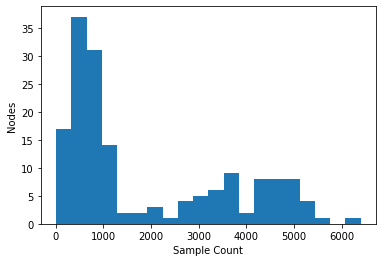

In [6]:
# The number of samples from each data is different
# Show a histogram of the number of samples in the 4 days data

count_train= []
for d in dataset['data']:
    count_train.append(d.shape[0])
plt.hist(count_train,20)
plt.ylabel('Nodes')
plt.xlabel('Sample Count')
print("Node Count",len(count_train))
print(np.sum(count_train))
print(np.median(count_train))

Node Count 149
83806


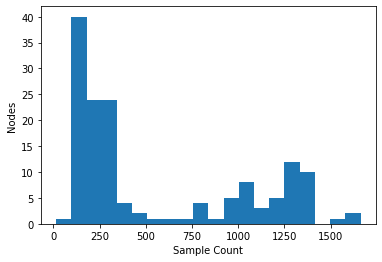

In [7]:
# Show a histogram of the number of samples in the last day data
count_test= []
for d in test_dataset['data']:
    count_test.append(d.shape[0])
plt.hist(count_test,20)
plt.ylabel('Nodes')
plt.xlabel('Sample Count')
print("Node Count",len(count_test))
print(np.sum(count_test))

In [8]:
# A random list of transmitters
seq = [110,112,143,7,44,101,122,66,85,86,133,92,26,146,119,62,51,97,128,90,45,56,59,8,37,33,147,61,98,121,135,24,54,80,19,74,131,16,60,120,40,22,63,151,111,145,136,27,118,95]

In [9]:
# Number of samples in this random list
np.sum(np.array(count_train)[np.array(seq)])

92318

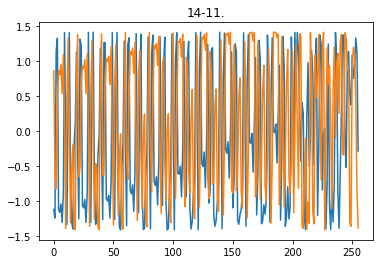

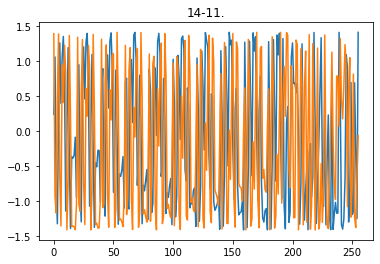

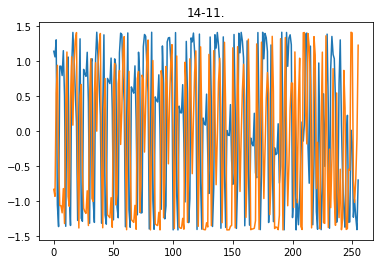

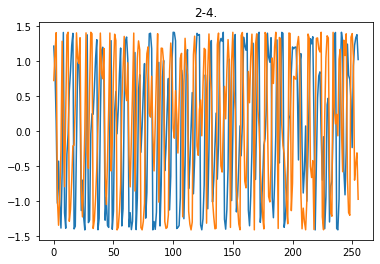

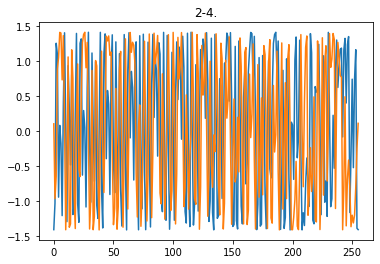

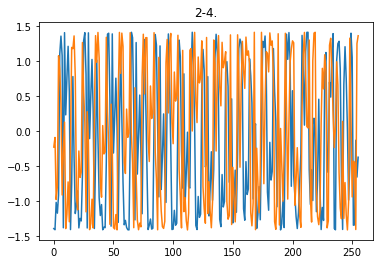

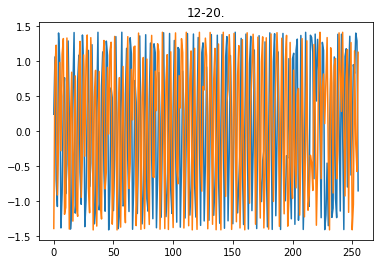

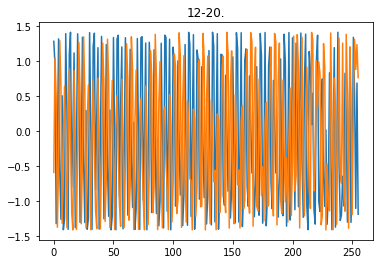

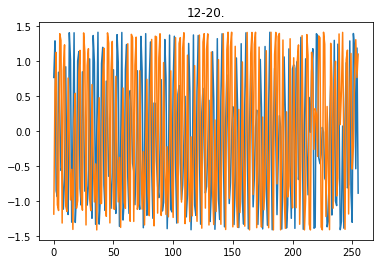

In [13]:
# visualize some samples
ntx = 3
nsamps = 3

from data_loader import norm
np.random.seed(0)
for j in range(ntx):
    tx = np.random.randint(len(dataset['data']))
    nm = dataset['node_list'][tx]
    for ii in range(nsamps):
        i = np.random.randint(dataset['data'][tx].shape[0])
        d = norm(dataset['data'][tx][i])
        plt.figure()
        plt.title(nm)
        plt.plot(d)